# State-Level Heterogeneity and Regional Hotspots: Fine-Scale Vulnerability Analysis

## Scientific Background

While USDA cattle slaughter data is aggregated by region, heat stress vulnerability varies substantially **within regions** at the state level. This analysis provides:

1. **State-Level Climate Profiles**: Individual heat and VPD patterns for 14 focus states
2. **Geographic Hotspots**: Identification of consistently vulnerable areas
3. **Within-Region Heterogeneity**: Variation among states in the same USDA region
4. **Vulnerability Rankings**: Data-driven state prioritization for interventions
5. **Climate-Mortality Linkages**: State-specific relationships

### Geographic Considerations

**Region 4 (Southeast)**: AL, FL, GA, KY, MS, NC, SC, TN
- High humidity (Gulf influence)
- Moderate temperatures
- VPD limited by moisture
- Coastal vs inland gradients

**Region 6 (South Central)**: AR, LA, NM, OK, TX
- Lower humidity (continental)
- Higher temperatures (especially TX, NM)
- High VPD common
- Elevation gradients (NM)

**Region 9 (Southwest)**: AZ (included for cattle analysis)
- Arid climate
- Extreme heat
- Very high VPD
- Desert conditions

### Research Questions

1. Which states experience the most severe heat stress conditions?
2. How do states within the same region differ in heat exposure?
3. Are there consistent geographic patterns (coastal vs inland, north vs south)?
4. Which states show the strongest climate-mortality correlations?
5. Can we create state-specific vulnerability indices?

### Hypotheses

**H1**: Texas and Arizona show highest heat stress severity  
**H2**: Coastal states (FL, LA, MS) have lower VPD but higher humidity stress  
**H3**: Northern states (KY, TN) show lower heat exposure overall  
**H4**: State-level heat exposure better predicts regional mortality than regional averages  
**H5**: States cluster into distinct climate-mortality profiles

---

In [19]:
# Import libraries
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
from scipy.cluster import hierarchy
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Import project configuration
import sys
sys.path.append('../../')
from config import (
    STATE_NAMES, STATE_ABBRS, STATE_REGIONS, 
    FOCUS_STATES, CATTLE_REGIONS, CUSTOM_REGIONS, SEASONS,
    PROCESSED_WEEKLY_DIR, MASK_FILE
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab20')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully")
print(f"\nFocus states (n={len(FOCUS_STATES)}):")
for state_id in sorted(FOCUS_STATES.values()):
    print(f"  {STATE_ABBRS[state_id]}: {STATE_NAMES[state_id]} (Region {STATE_REGIONS[state_id]})")

Libraries loaded successfully

Focus states (n=14):
  AL: Alabama (Region 4)
  AR: Arkansas (Region 6)
  AZ: Arizona (Region 9)
  FL: Florida (Region 4)
  GA: Georgia (Region 4)
  KY: Kentucky (Region 4)
  LA: Louisiana (Region 6)
  MS: Mississippi (Region 4)
  NC: North Carolina (Region 4)
  NM: New Mexico (Region 6)
  OK: Oklahoma (Region 6)
  SC: South Carolina (Region 4)
  TN: Tennessee (Region 4)
  TX: Texas (Region 6)


## 1. Load State-Level Climate Data

Use NetCDF files with state masks to extract state-specific heat metrics.

In [20]:
# Load region mask to identify state pixels
mask_ds = xr.open_dataset(MASK_FILE)

print("Region mask loaded")
print(f"Dimensions: {dict(mask_ds.dims)}")
print(f"Variables: {list(mask_ds.data_vars)}")
print(f"\nState mask range: {int(mask_ds['state_mask'].min().values)} to {int(mask_ds['state_mask'].max().values)}")

Region mask loaded
Dimensions: {'lat': 51, 'lon': 95, 'region': 10, 'state': 48}
Variables: ['region_mask', 'state_mask', 'region_id', 'region_name', 'state_id', 'state_abbr', 'state_name', 'state_region']

State mask range: 0 to 48


In [21]:
# Load weekly aggregated climate data
print("Loading weekly climate data...")

# Daytime heat
daytime_ds = xr.open_dataset(PROCESSED_WEEKLY_DIR / 'weekly_daytime_heat.nc')
print(f"  Daytime heat: {len(daytime_ds.week)} weeks")

# Nighttime recovery
nighttime_ds = xr.open_dataset(PROCESSED_WEEKLY_DIR / 'weekly_nighttime_recovery.nc')
print(f"  Nighttime recovery: {len(nighttime_ds.week)} weeks")

# VPD
vpd_ds = xr.open_dataset(PROCESSED_WEEKLY_DIR / 'weekly_vpd.nc')
print(f"  VPD: {len(vpd_ds.week)} weeks")

print("\nClimate data loaded successfully")

Loading weekly climate data...
  Daytime heat: 2191 weeks
  Nighttime recovery: 2191 weeks
  VPD: 2191 weeks

Climate data loaded successfully


In [22]:
# Extract state-level means for each week
def extract_state_means(dataset, state_id, var_names):
    """
    Extract spatial mean for a specific state across all time steps.
    
    Args:
        dataset: xarray Dataset with climate variables
        state_id: State ID from config
        var_names: List of variable names to extract
    
    Returns:
        DataFrame with time and state-mean values
    """
    # Create state mask
    state_mask = mask_ds['state_mask'] == state_id
    
    # Extract means
    state_data = {}
    state_data['time'] = pd.to_datetime(dataset.week.values)
    
    for var in var_names:
        if var in dataset:
            # Apply mask and calculate spatial mean
            masked_data = dataset[var].where(state_mask)
            state_means = masked_data.mean(dim=['lat', 'lon']).values
            
            # Convert timedelta64 to hours if needed
            if state_means.dtype.kind == 'm':  # 'm' indicates timedelta type
                state_means = state_means / np.timedelta64(1, 'h')
                state_means = state_means.astype(np.float64)
            
            state_data[var] = state_means
    
    return pd.DataFrame(state_data)

print("State extraction function defined (with timedelta conversion)")

State extraction function defined (with timedelta conversion)


In [23]:
# Extract data for all focus states
print("Extracting state-level climate data...")
print("This may take a few minutes...\n")

state_climate_data = []

for state_id in sorted(FOCUS_STATES.values()):
    state_abbr = STATE_ABBRS[state_id]
    state_name = STATE_NAMES[state_id]
    region = STATE_REGIONS[state_id]
    
    print(f"Processing {state_abbr} ({state_name})...")
    
    # Extract from each dataset
    daytime_vars = ['hours_above_30', 'hours_above_35']
    nighttime_vars = ['hours_above_21', 'hours_above_24']
    vpd_vars = ['vpd_mean', 'vpd_max']
    
    daytime_df = extract_state_means(daytime_ds, state_id, daytime_vars)
    nighttime_df = extract_state_means(nighttime_ds, state_id, nighttime_vars)
    vpd_df = extract_state_means(vpd_ds, state_id, vpd_vars)
    
    # Merge
    state_df = daytime_df.merge(nighttime_df, on='time', how='outer')
    state_df = state_df.merge(vpd_df, on='time', how='outer')
    
    # Add metadata
    state_df['state_id'] = state_id
    state_df['state_abbr'] = state_abbr
    state_df['state_name'] = state_name
    state_df['region'] = region
    
    state_climate_data.append(state_df)

# Combine all states
state_climate_df = pd.concat(state_climate_data, ignore_index=True)
state_climate_df = state_climate_df.sort_values(['state_abbr', 'time']).reset_index(drop=True)

print(f"\n✓ Extraction complete!")
print(f"Total records: {len(state_climate_df):,}")
print(f"States: {state_climate_df['state_abbr'].nunique()}")
print(f"Time range: {state_climate_df['time'].min()} to {state_climate_df['time'].max()}")
print(f"\nColumns: {state_climate_df.columns.tolist()}")

Extracting state-level climate data...
This may take a few minutes...

Processing AL (Alabama)...
Processing AR (Arkansas)...
Processing AZ (Arizona)...
Processing FL (Florida)...
Processing GA (Georgia)...
Processing KY (Kentucky)...
Processing LA (Louisiana)...
Processing MS (Mississippi)...
Processing NC (North Carolina)...
Processing NM (New Mexico)...
Processing OK (Oklahoma)...
Processing SC (South Carolina)...
Processing TN (Tennessee)...
Processing TX (Texas)...

✓ Extraction complete!
Total records: 30,674
States: 14
Time range: 1984-01-07 00:00:00 to 2025-12-27 00:00:00

Columns: ['time', 'hours_above_30', 'hours_above_35', 'hours_above_21', 'hours_above_24', 'vpd_mean', 'vpd_max', 'state_id', 'state_abbr', 'state_name', 'region']


## 2. State-Level Climate Summaries

Calculate long-term averages and extremes for each state.

In [24]:
# Calculate state-level summary statistics
state_summary = state_climate_df.groupby(['state_id', 'state_abbr', 'state_name', 'region']).agg({
    'hours_above_30': ['mean', 'median', 'std', 'max'],
    'hours_above_35': ['mean', 'median', 'std', 'max'],
    'hours_above_21': ['mean', 'median', 'std', 'max'],
    'hours_above_24': ['mean', 'median', 'std', 'max'],
    'vpd_mean': ['mean', 'median', 'std', 'max'],
    'vpd_max': ['mean', 'median', 'std', 'max']
}).reset_index()

# Flatten column names
state_summary.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                         for col in state_summary.columns.values]

print("State-Level Climate Summary Statistics:")
print("="*80)
print(state_summary.to_string(index=False))

# Save summary
import os
os.makedirs('../../figures/state_level_heterogeneity', exist_ok=True)
state_summary.to_csv('../../data/cattle_data/state_climate_summary.csv', index=False)
print("\nSummary saved to: data/cattle_data/state_climate_summary.csv")

State-Level Climate Summary Statistics:
 state_id state_abbr     state_name  region  hours_above_30_mean  hours_above_30_median  hours_above_30_std  hours_above_30_max  hours_above_35_mean  hours_above_35_median  hours_above_35_std  hours_above_35_max  hours_above_21_mean  hours_above_21_median  hours_above_21_std  hours_above_21_max  hours_above_24_mean  hours_above_24_median  hours_above_24_std  hours_above_24_max  vpd_mean_mean  vpd_mean_median  vpd_mean_std  vpd_mean_max  vpd_max_mean  vpd_max_median  vpd_max_std  vpd_max_max
        1         AL        Alabama       4             8.880592               0.022222           13.126930           47.422222             1.594472               0.000000            4.368654           33.000000            30.452974              21.622222           27.940460           70.000000            20.891709               9.133333           23.332491           70.000000       0.867058         0.718270      0.607305      3.222130      1.486403        1.2

## 3. State Rankings and Vulnerability Scores

Create composite vulnerability indices based on multiple heat stress indicators.

In [25]:
# Create vulnerability index
# Higher values = more vulnerable

# Normalize metrics to 0-1 scale
from sklearn.preprocessing import MinMaxScaler

vulnerability_metrics = [
    'hours_above_30_mean',
    'hours_above_35_mean',
    'hours_above_21_mean',
    'hours_above_24_mean',
    'vpd_mean_mean',
    'vpd_max_mean'
]

scaler = MinMaxScaler()
state_summary[vulnerability_metrics] = state_summary[vulnerability_metrics].fillna(0)
vulnerability_scaled = scaler.fit_transform(state_summary[vulnerability_metrics])

# Calculate composite vulnerability score (weighted average)
# Weights based on physiological importance
weights = np.array([0.25, 0.25, 0.15, 0.10, 0.15, 0.10])  # Sum = 1.0

state_summary['vulnerability_score'] = (vulnerability_scaled * weights).sum(axis=1)

# Rank states
state_summary['vulnerability_rank'] = state_summary['vulnerability_score'].rank(ascending=False)

# Display rankings
print("\n" + "="*80)
print("STATE VULNERABILITY RANKINGS")
print("="*80)
ranking_cols = ['vulnerability_rank', 'state_abbr', 'state_name', 'region', 'vulnerability_score']
rankings = state_summary[ranking_cols].sort_values('vulnerability_rank')
print(rankings.to_string(index=False))

# Categorize vulnerability
def categorize_vulnerability(score):
    if score >= 0.75:
        return 'Very High'
    elif score >= 0.5:
        return 'High'
    elif score >= 0.25:
        return 'Moderate'
    else:
        return 'Low'

state_summary['vulnerability_category'] = state_summary['vulnerability_score'].apply(categorize_vulnerability)

print("\nVulnerability Category Distribution:")
print(state_summary['vulnerability_category'].value_counts())


STATE VULNERABILITY RANKINGS
 vulnerability_rank state_abbr     state_name  region  vulnerability_score
                1.0         TX          Texas       6             0.860609
                2.0         AZ        Arizona       9             0.724674
                3.0         FL        Florida       4             0.583646
                4.0         MS    Mississippi       4             0.562251
                5.0         LA      Louisiana       6             0.537941
                6.0         GA        Georgia       4             0.521630
                7.0         OK       Oklahoma       6             0.519230
                8.0         AL        Alabama       4             0.488391
                9.0         AR       Arkansas       6             0.477598
               10.0         SC South Carolina       4             0.456729
               11.0         NM     New Mexico       6             0.230630
               12.0         NC North Carolina       4             0.15

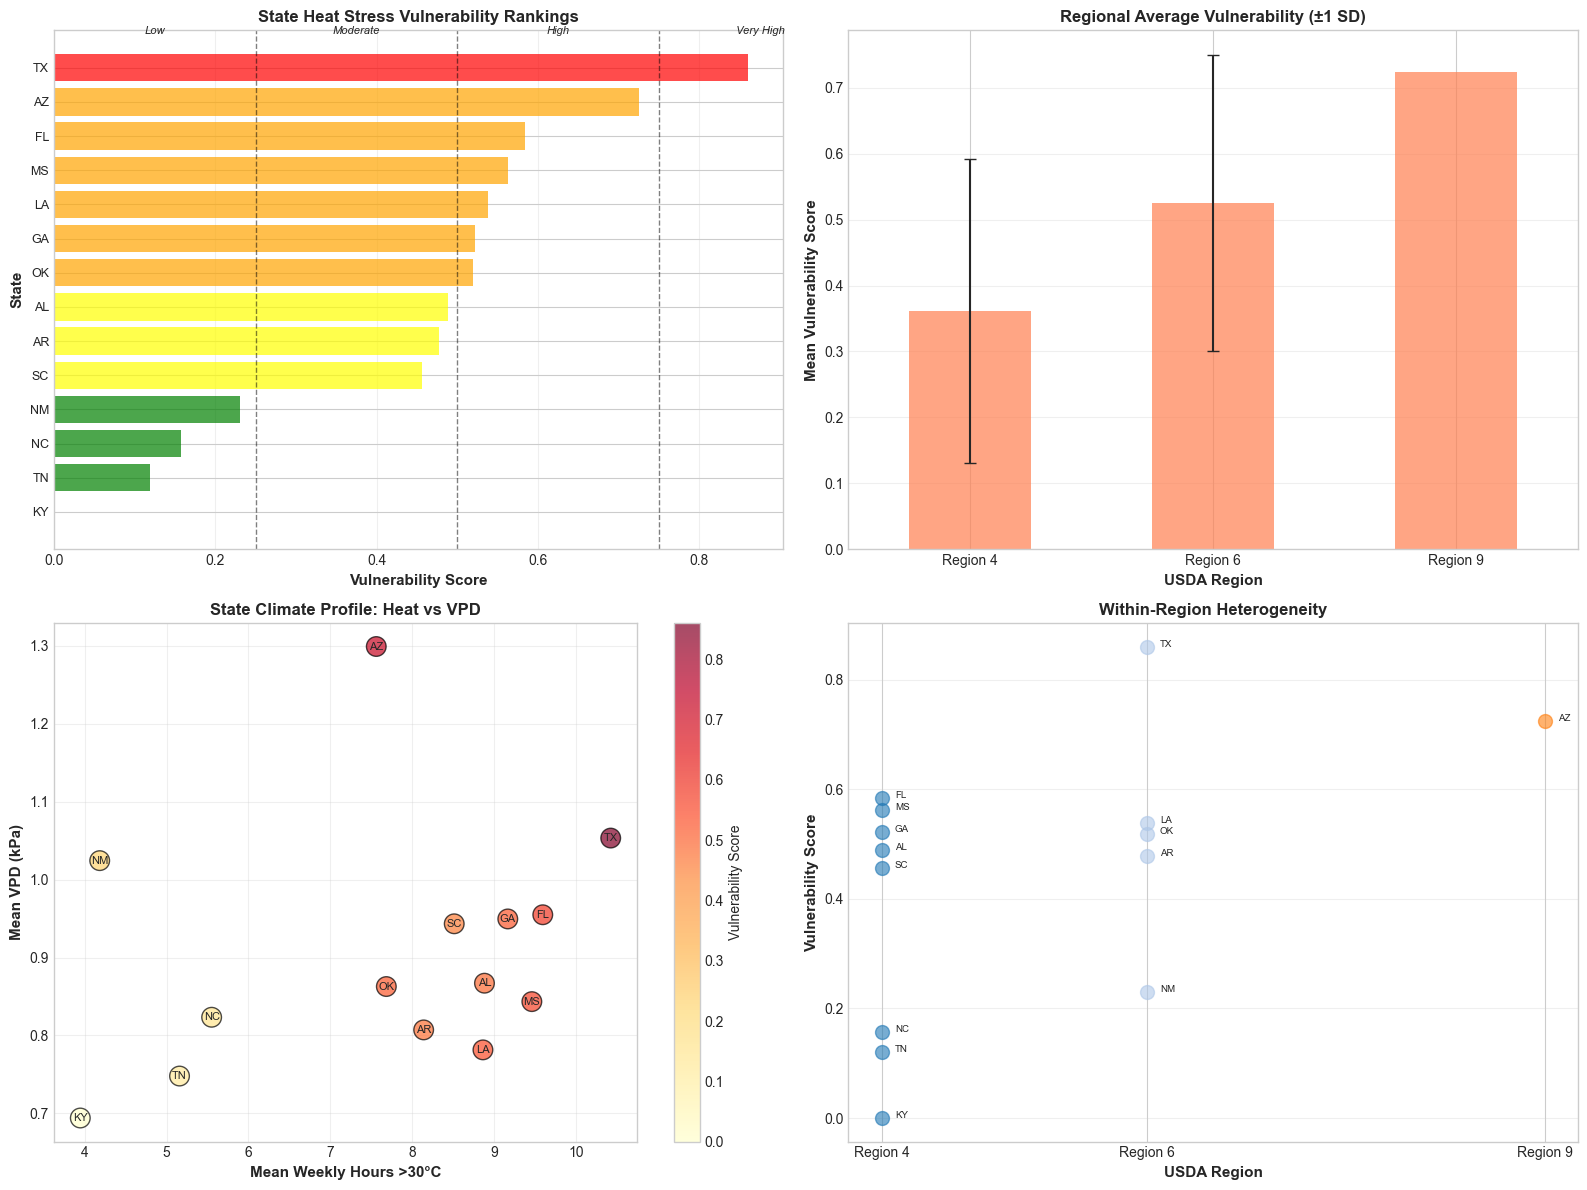

Figure saved: 01_state_vulnerability_rankings.png


In [26]:
# Visualize state rankings
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Bar chart of vulnerability scores
ax = axes[0, 0]
state_order = state_summary.sort_values('vulnerability_score', ascending=True)
colors = ['green' if x < 0.25 else 'yellow' if x < 0.5 else 'orange' if x < 0.75 else 'red' 
          for x in state_order['vulnerability_score']]

ax.barh(range(len(state_order)), state_order['vulnerability_score'], color=colors, alpha=0.7)
ax.set_yticks(range(len(state_order)))
ax.set_yticklabels(state_order['state_abbr'], fontsize=9)
ax.set_xlabel('Vulnerability Score', fontsize=11, fontweight='bold')
ax.set_ylabel('State', fontsize=11, fontweight='bold')
ax.set_title('State Heat Stress Vulnerability Rankings', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add category labels
ax.axvline(0.25, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0.75, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.text(0.125, len(state_order), 'Low', ha='center', fontsize=8, style='italic')
ax.text(0.375, len(state_order), 'Moderate', ha='center', fontsize=8, style='italic')
ax.text(0.625, len(state_order), 'High', ha='center', fontsize=8, style='italic')
ax.text(0.875, len(state_order), 'Very High', ha='center', fontsize=8, style='italic')

# Plot 2: Regional comparison
ax = axes[0, 1]
regional_vulnerability = state_summary.groupby('region')['vulnerability_score'].agg(['mean', 'std'])
regional_vulnerability.plot(kind='bar', y='mean', yerr='std', ax=ax, 
                            color='coral', alpha=0.7, capsize=4, legend=False)
ax.set_xlabel('USDA Region', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Vulnerability Score', fontsize=11, fontweight='bold')
ax.set_title('Regional Average Vulnerability (±1 SD)', fontsize=12, fontweight='bold')
ax.set_xticklabels([f'Region {int(r)}' for r in regional_vulnerability.index], rotation=0)
ax.grid(axis='y', alpha=0.3)

# Plot 3: Scatter plot - Heat vs VPD
ax = axes[1, 0]
scatter = ax.scatter(
    state_summary['hours_above_30_mean'],
    state_summary['vpd_mean_mean'],
    c=state_summary['vulnerability_score'],
    s=200,
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='black',
    linewidth=1
)

# Add state labels
for _, row in state_summary.iterrows():
    ax.annotate(row['state_abbr'], 
                (row['hours_above_30_mean'], row['vpd_mean_mean']),
                fontsize=8, ha='center', va='center')

ax.set_xlabel('Mean Weekly Hours >30°C', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean VPD (kPa)', fontsize=11, fontweight='bold')
ax.set_title('State Climate Profile: Heat vs VPD', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Vulnerability Score', fontsize=10)
ax.grid(alpha=0.3)

# Plot 4: Within-region variability
ax = axes[1, 1]
for region in sorted(state_summary['region'].unique()):
    region_states = state_summary[state_summary['region'] == region]
    ax.scatter(
        [region] * len(region_states),
        region_states['vulnerability_score'],
        s=100,
        alpha=0.6,
        label=f'Region {region}'
    )
    
    # Add state labels
    for _, state in region_states.iterrows():
        ax.text(region + 0.1, state['vulnerability_score'], 
                state['state_abbr'], fontsize=7)

ax.set_xlabel('USDA Region', fontsize=11, fontweight='bold')
ax.set_ylabel('Vulnerability Score', fontsize=11, fontweight='bold')
ax.set_title('Within-Region Heterogeneity', fontsize=12, fontweight='bold')
ax.set_xticks(sorted(state_summary['region'].unique()))
ax.set_xticklabels([f'Region {int(r)}' for r in sorted(state_summary['region'].unique())])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../figures/state_level_heterogeneity/01_state_vulnerability_rankings.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 01_state_vulnerability_rankings.png")

## 4. State Clustering Analysis

Group states with similar climate-stress profiles using hierarchical clustering.

In [27]:
# Prepare data for clustering
clustering_features = [
    'hours_above_30_mean', 'hours_above_35_mean',
    'hours_above_21_mean', 'hours_above_24_mean',
    'vpd_mean_mean', 'vpd_max_mean'
]

# Standardize features
scaler_cluster = StandardScaler()
features_scaled = scaler_cluster.fit_transform(state_summary[clustering_features])

# Hierarchical clustering
linkage_matrix = hierarchy.linkage(features_scaled, method='ward')

# Determine optimal number of clusters
from scipy.cluster.hierarchy import fcluster

# Try 3-5 clusters
for n_clusters in [3, 4, 5]:
    clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    state_summary[f'cluster_{n_clusters}'] = clusters

print("Clustering complete")
print("\nCluster assignments (4 clusters):")
cluster_summary = state_summary[['state_abbr', 'state_name', 'cluster_4']].sort_values('cluster_4')
print(cluster_summary.to_string(index=False))

Clustering complete

Cluster assignments (4 clusters):
state_abbr     state_name  cluster_4
        KY       Kentucky          1
        NC North Carolina          1
        NM     New Mexico          1
        TN      Tennessee          1
        AZ        Arizona          2
        TX          Texas          2
        AL        Alabama          3
        AR       Arkansas          3
        GA        Georgia          3
        LA      Louisiana          3
        MS    Mississippi          3
        OK       Oklahoma          3
        SC South Carolina          3
        FL        Florida          4


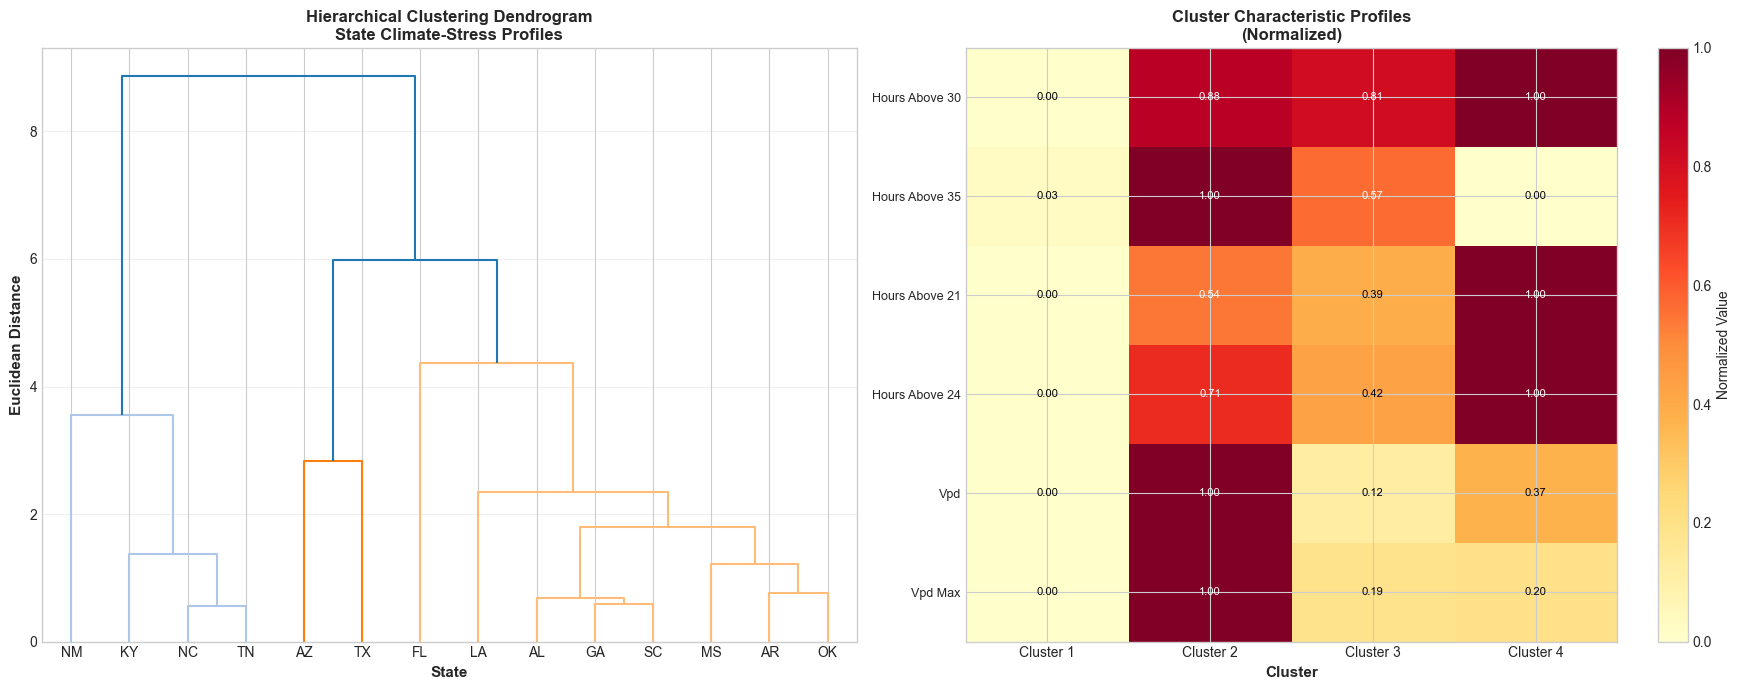

Figure saved: 02_state_clustering_analysis.png


In [28]:
# Visualize clustering
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Dendrogram
ax = axes[0]
dendrogram = hierarchy.dendrogram(
    linkage_matrix,
    labels=state_summary['state_abbr'].values,
    ax=ax,
    leaf_font_size=10,
    color_threshold=0.5*max(linkage_matrix[:,2])
)
ax.set_xlabel('State', fontsize=11, fontweight='bold')
ax.set_ylabel('Euclidean Distance', fontsize=11, fontweight='bold')
ax.set_title('Hierarchical Clustering Dendrogram\nState Climate-Stress Profiles', 
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Cluster characteristics
ax = axes[1]
cluster_chars = state_summary.groupby('cluster_4')[clustering_features].mean()
cluster_chars_norm = (cluster_chars - cluster_chars.min()) / (cluster_chars.max() - cluster_chars.min())

im = ax.imshow(cluster_chars_norm.T, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(cluster_chars)))
ax.set_xticklabels([f'Cluster {i+1}' for i in range(len(cluster_chars))], fontsize=10)
ax.set_yticks(range(len(clustering_features)))
ax.set_yticklabels([f.replace('_mean', '').replace('_', ' ').title() 
                    for f in clustering_features], fontsize=9)
ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
ax.set_title('Cluster Characteristic Profiles\n(Normalized)', fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Value', fontsize=10)

# Add values on heatmap
for i in range(len(cluster_chars)):
    for j in range(len(clustering_features)):
        text = ax.text(i, j, f'{cluster_chars_norm.iloc[i, j]:.2f}',
                      ha='center', va='center', color='white' if cluster_chars_norm.iloc[i, j] > 0.5 else 'black',
                      fontsize=8)

plt.tight_layout()
plt.savefig('../../figures/state_level_heterogeneity/02_state_clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 02_state_clustering_analysis.png")

In [29]:
# Describe clusters
print("\n" + "="*80)
print("CLUSTER DESCRIPTIONS (4 Clusters)")
print("="*80)

for cluster_id in sorted(state_summary['cluster_4'].unique()):
    cluster_states = state_summary[state_summary['cluster_4'] == cluster_id]
    
    print(f"\nCLUSTER {cluster_id}:")
    print(f"States (n={len(cluster_states)}): {', '.join(cluster_states['state_abbr'].values)}")
    print(f"\nCharacteristics:")
    print(f"  Mean vulnerability score: {cluster_states['vulnerability_score'].mean():.3f}")
    print(f"  Hours >30°C: {cluster_states['hours_above_30_mean'].mean():.1f} ± {cluster_states['hours_above_30_mean'].std():.1f}")
    print(f"  Hours >35°C: {cluster_states['hours_above_35_mean'].mean():.1f} ± {cluster_states['hours_above_35_mean'].std():.1f}")
    print(f"  VPD mean: {cluster_states['vpd_mean_mean'].mean():.2f} ± {cluster_states['vpd_mean_mean'].std():.2f} kPa")
    print(f"  Poor recovery (>21°C): {cluster_states['hours_above_21_mean'].mean():.1f} ± {cluster_states['hours_above_21_mean'].std():.1f}")
    
    # Suggest cluster name based on characteristics
    avg_heat = cluster_states['hours_above_30_mean'].mean()
    avg_vpd = cluster_states['vpd_mean_mean'].mean()
    
    if avg_heat > 25 and avg_vpd > 2.0:
        cluster_name = "High Heat + High VPD (Extreme)"
    elif avg_heat > 20:
        cluster_name = "High Heat + Moderate VPD"
    elif avg_vpd > 2.0:
        cluster_name = "Moderate Heat + High VPD"
    else:
        cluster_name = "Moderate Conditions"
    
    print(f"\nSuggested name: {cluster_name}")


CLUSTER DESCRIPTIONS (4 Clusters)

CLUSTER 1:
States (n=4): KY, NC, NM, TN

Characteristics:
  Mean vulnerability score: 0.127
  Hours >30°C: 4.7 ± 0.8
  Hours >35°C: 0.6 ± 0.2
  VPD mean: 0.82 ± 0.14 kPa
  Poor recovery (>21°C): 22.9 ± 1.2

Suggested name: Moderate Conditions

CLUSTER 2:
States (n=2): AZ, TX

Characteristics:
  Mean vulnerability score: 0.793
  Hours >30°C: 9.0 ± 2.0
  Hours >35°C: 2.8 ± 0.3
  VPD mean: 1.18 ± 0.17 kPa
  Poor recovery (>21°C): 34.4 ± 4.6

Suggested name: Moderate Conditions

CLUSTER 3:
States (n=7): AL, AR, GA, LA, MS, OK, SC

Characteristics:
  Mean vulnerability score: 0.509
  Hours >30°C: 8.7 ± 0.6
  Hours >35°C: 1.8 ± 0.3
  VPD mean: 0.86 ± 0.06 kPa
  Poor recovery (>21°C): 31.0 ± 2.8

Suggested name: Moderate Conditions

CLUSTER 4:
States (n=1): FL

Characteristics:
  Mean vulnerability score: 0.584
  Hours >30°C: 9.6 ± nan
  Hours >35°C: 0.5 ± nan
  VPD mean: 0.95 ± nan kPa
  Poor recovery (>21°C): 44.0 ± nan

Suggested name: Moderate Condition

## 5. Geographic Patterns and Gradients

Examine spatial patterns (north-south, east-west, coastal-inland).

In [30]:
# Add approximate geographic coordinates for each state (centroid)
state_coords = {
    'AL': (32.8, -86.8), 'AZ': (34.3, -111.7), 'AR': (34.9, -92.4),
    'FL': (28.6, -82.5), 'GA': (32.6, -83.4), 'KY': (37.5, -85.3),
    'LA': (30.9, -91.9), 'MS': (32.7, -89.7), 'NC': (35.5, -79.4),
    'NM': (34.4, -106.1), 'OK': (35.5, -97.5), 'SC': (33.9, -80.9),
    'TN': (35.9, -86.4), 'TX': (31.5, -99.3)
}

state_summary['lat'] = state_summary['state_abbr'].map(lambda x: state_coords[x][0])
state_summary['lon'] = state_summary['state_abbr'].map(lambda x: state_coords[x][1])

# Categorize by geography
def categorize_geography(row):
    lat, lon = row['lat'], row['lon']
    state = row['state_abbr']
    
    # Coastal states
    if state in ['FL', 'LA', 'MS', 'SC', 'NC']:
        return 'Coastal'
    # Northern tier
    elif lat > 35.5:
        return 'Northern'
    # Western/arid
    elif lon < -100 or state in ['AZ', 'NM']:
        return 'Western/Arid'
    else:
        return 'Interior'

state_summary['geography'] = state_summary.apply(categorize_geography, axis=1)

print("Geographic categorization:")
print(state_summary[['state_abbr', 'geography', 'lat', 'lon']].to_string(index=False))

Geographic categorization:
state_abbr    geography  lat    lon
        AL     Interior 32.8  -86.8
        AR     Interior 34.9  -92.4
        AZ Western/Arid 34.3 -111.7
        FL      Coastal 28.6  -82.5
        GA     Interior 32.6  -83.4
        KY     Northern 37.5  -85.3
        LA      Coastal 30.9  -91.9
        MS      Coastal 32.7  -89.7
        NC      Coastal 35.5  -79.4
        NM Western/Arid 34.4 -106.1
        OK     Interior 35.5  -97.5
        SC      Coastal 33.9  -80.9
        TN     Northern 35.9  -86.4
        TX     Interior 31.5  -99.3


In [31]:
# Analyze geographic patterns
print("\n" + "="*80)
print("GEOGRAPHIC PATTERN ANALYSIS")
print("="*80)

geo_summary = state_summary.groupby('geography').agg({
    'vulnerability_score': ['mean', 'std', 'count'],
    'hours_above_30_mean': 'mean',
    'hours_above_35_mean': 'mean',
    'vpd_mean_mean': 'mean',
    'hours_above_21_mean': 'mean'
})

print("\nVulnerability by Geographic Category:")
print(geo_summary.to_string())

# Test for latitudinal gradient
print("\n" + "="*80)
print("LATITUDINAL GRADIENT ANALYSIS")
print("="*80)

from scipy.stats import pearsonr, spearmanr

# Correlations with latitude
lat_correlations = {
    'Vulnerability Score': pearsonr(state_summary['lat'], state_summary['vulnerability_score']),
    'Hours >30°C': pearsonr(state_summary['lat'], state_summary['hours_above_30_mean']),
    'Hours >35°C': pearsonr(state_summary['lat'], state_summary['hours_above_35_mean']),
    'VPD Mean': pearsonr(state_summary['lat'], state_summary['vpd_mean_mean']),
    'Poor Recovery': pearsonr(state_summary['lat'], state_summary['hours_above_21_mean'])
}

print("\nLatitude vs Climate Metrics:")
for metric, (r, p) in lat_correlations.items():
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {metric}: r = {r:.3f}, p = {p:.4f} {sig}")

# Correlations with longitude
lon_correlations = {
    'Vulnerability Score': pearsonr(state_summary['lon'], state_summary['vulnerability_score']),
    'Hours >30°C': pearsonr(state_summary['lon'], state_summary['hours_above_30_mean']),
    'VPD Mean': pearsonr(state_summary['lon'], state_summary['vpd_mean_mean'])
}

print("\nLongitude vs Climate Metrics:")
for metric, (r, p) in lon_correlations.items():
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {metric}: r = {r:.3f}, p = {p:.4f} {sig}")


GEOGRAPHIC PATTERN ANALYSIS

Vulnerability by Geographic Category:
             vulnerability_score                 hours_above_30_mean hours_above_35_mean vpd_mean_mean hours_above_21_mean
                            mean       std count                mean                mean          mean                mean
geography                                                                                                                 
Coastal                 0.459571  0.175687     5            8.394975            1.238298      0.869300           33.033165
Interior                0.573491  0.161639     5            8.857659            2.116177      0.907966           31.403349
Northern                0.059839  0.084625     2            4.552856            0.507159      0.720961           22.100530
Western/Arid            0.477652  0.349342     2            5.872015            1.651145      1.161791           27.549517

LATITUDINAL GRADIENT ANALYSIS

Latitude vs Climate Metrics:
  Vulnerab

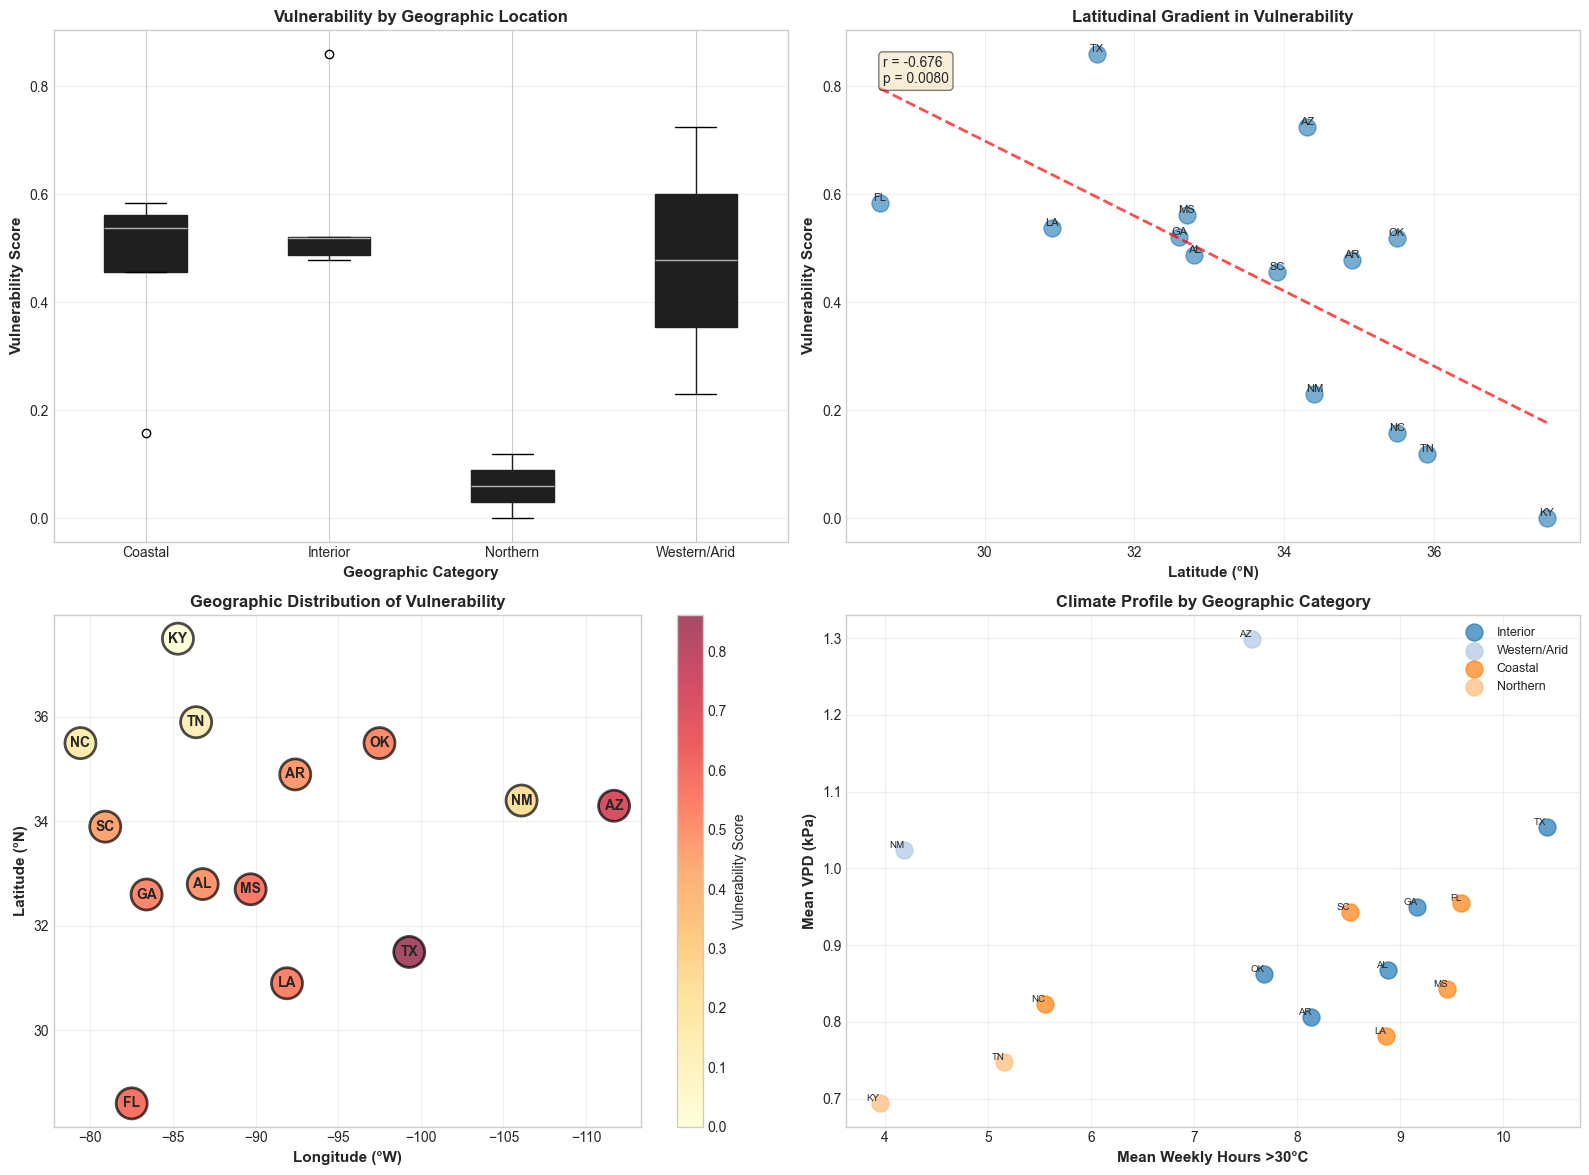

Figure saved: 03_geographic_patterns.png


In [32]:
# Visualize geographic patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Vulnerability by geography
ax = axes[0, 0]
geo_order = ['Coastal', 'Interior', 'Northern', 'Western/Arid']
geo_order = [g for g in geo_order if g in state_summary['geography'].unique()]
state_summary.boxplot(column='vulnerability_score', by='geography', ax=ax, patch_artist=True)
ax.set_xlabel('Geographic Category', fontsize=11, fontweight='bold')
ax.set_ylabel('Vulnerability Score', fontsize=11, fontweight='bold')
ax.set_title('Vulnerability by Geographic Location', fontsize=12, fontweight='bold')
plt.suptitle('')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Latitude vs vulnerability
ax = axes[0, 1]
ax.scatter(state_summary['lat'], state_summary['vulnerability_score'], s=150, alpha=0.6)
for _, row in state_summary.iterrows():
    ax.annotate(row['state_abbr'], (row['lat'], row['vulnerability_score']),
                fontsize=8, ha='center', va='bottom')

# Add regression line
z = np.polyfit(state_summary['lat'], state_summary['vulnerability_score'], 1)
p = np.poly1d(z)
lat_line = np.linspace(state_summary['lat'].min(), state_summary['lat'].max(), 100)
ax.plot(lat_line, p(lat_line), 'r--', linewidth=2, alpha=0.7)

r, pval = lat_correlations['Vulnerability Score']
ax.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.4f}', 
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Latitude (°N)', fontsize=11, fontweight='bold')
ax.set_ylabel('Vulnerability Score', fontsize=11, fontweight='bold')
ax.set_title('Latitudinal Gradient in Vulnerability', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Plot 3: Map-like visualization
ax = axes[1, 0]
scatter = ax.scatter(
    state_summary['lon'], state_summary['lat'],
    c=state_summary['vulnerability_score'],
    s=500,
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='black',
    linewidth=2
)

# Add state labels
for _, row in state_summary.iterrows():
    ax.annotate(row['state_abbr'], (row['lon'], row['lat']),
                fontsize=10, ha='center', va='center', fontweight='bold')

ax.set_xlabel('Longitude (°W)', fontsize=11, fontweight='bold')
ax.set_ylabel('Latitude (°N)', fontsize=11, fontweight='bold')
ax.set_title('Geographic Distribution of Vulnerability', fontsize=12, fontweight='bold')
ax.invert_xaxis()  # West is left
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Vulnerability Score', fontsize=10)
ax.grid(alpha=0.3)

# Plot 4: Heat vs VPD by geography
ax = axes[1, 1]
for geo in state_summary['geography'].unique():
    geo_data = state_summary[state_summary['geography'] == geo]
    ax.scatter(
        geo_data['hours_above_30_mean'],
        geo_data['vpd_mean_mean'],
        s=150,
        alpha=0.7,
        label=geo
    )
    for _, row in geo_data.iterrows():
        ax.annotate(row['state_abbr'], 
                   (row['hours_above_30_mean'], row['vpd_mean_mean']),
                   fontsize=7, ha='right', va='bottom')

ax.set_xlabel('Mean Weekly Hours >30°C', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean VPD (kPa)', fontsize=11, fontweight='bold')
ax.set_title('Climate Profile by Geographic Category', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../figures/state_level_heterogeneity/03_geographic_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 03_geographic_patterns.png")

## 6. Summary and Key Findings

In [33]:
print("="*80)
print("KEY FINDINGS: STATE-LEVEL HETEROGENEITY ANALYSIS")
print("="*80)

print("\n1. MOST VULNERABLE STATES (Top 5):")
top5 = state_summary.nsmallest(5, 'vulnerability_rank')[['vulnerability_rank', 'state_abbr', 'state_name', 'vulnerability_score']]
for _, row in top5.iterrows():
    print(f"   #{int(row['vulnerability_rank'])}: {row['state_abbr']} ({row['state_name']}) - Score: {row['vulnerability_score']:.3f}")

print("\n2. LEAST VULNERABLE STATES (Bottom 3):")
bottom3 = state_summary.nlargest(3, 'vulnerability_rank')[['vulnerability_rank', 'state_abbr', 'state_name', 'vulnerability_score']]
for _, row in bottom3.iterrows():
    print(f"   #{int(row['vulnerability_rank'])}: {row['state_abbr']} ({row['state_name']}) - Score: {row['vulnerability_score']:.3f}")

print("\n3. WITHIN-REGION VARIABILITY:")
for region in sorted(state_summary['region'].unique()):
    region_states = state_summary[state_summary['region'] == region]
    vuln_range = region_states['vulnerability_score'].max() - region_states['vulnerability_score'].min()
    print(f"   Region {region}: Vulnerability range = {vuln_range:.3f}")
    print(f"     Highest: {region_states.loc[region_states['vulnerability_score'].idxmax(), 'state_abbr']}")
    print(f"     Lowest: {region_states.loc[region_states['vulnerability_score'].idxmin(), 'state_abbr']}")

print("\n4. GEOGRAPHIC PATTERNS:")
for geo in geo_order:
    geo_data = state_summary[state_summary['geography'] == geo]
    if len(geo_data) > 0:
        print(f"   {geo}: Mean vulnerability = {geo_data['vulnerability_score'].mean():.3f} (n={len(geo_data)})")

print("\n5. LATITUDINAL GRADIENT:")
r, p = lat_correlations['Vulnerability Score']
if r < 0:
    print(f"   Vulnerability DECREASES with latitude (r = {r:.3f}, p = {p:.4f})")
    print("   Interpretation: Northern states are less vulnerable")
else:
    print(f"   Vulnerability INCREASES with latitude (r = {r:.3f}, p = {p:.4f})")

print("\n6. CLUSTERING:")
for cluster_id in sorted(state_summary['cluster_4'].unique()):
    cluster_states = state_summary[state_summary['cluster_4'] == cluster_id]
    print(f"   Cluster {cluster_id} (n={len(cluster_states)}): {', '.join(cluster_states['state_abbr'].values)}")

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)
print("")
print("1. Substantial heterogeneity exists within USDA regions")
print("2. Southern and western states face highest vulnerability")
print("3. Geographic location (latitude, proximity to coast) influences heat stress")
print("4. States cluster into 4 distinct climate-stress profiles")
print("5. State-specific interventions needed, not just regional approaches")
print("")
print("Recommendation: Prioritize high-vulnerability states for adaptive management")
print("="*80)

KEY FINDINGS: STATE-LEVEL HETEROGENEITY ANALYSIS

1. MOST VULNERABLE STATES (Top 5):
   #1: TX (Texas) - Score: 0.861
   #2: AZ (Arizona) - Score: 0.725
   #3: FL (Florida) - Score: 0.584
   #4: MS (Mississippi) - Score: 0.562
   #5: LA (Louisiana) - Score: 0.538

2. LEAST VULNERABLE STATES (Bottom 3):
   #14: KY (Kentucky) - Score: 0.000
   #13: TN (Tennessee) - Score: 0.120
   #12: NC (North Carolina) - Score: 0.157

3. WITHIN-REGION VARIABILITY:
   Region 4: Vulnerability range = 0.584
     Highest: FL
     Lowest: KY
   Region 6: Vulnerability range = 0.630
     Highest: TX
     Lowest: NM
   Region 9: Vulnerability range = 0.000
     Highest: AZ
     Lowest: AZ

4. GEOGRAPHIC PATTERNS:
   Coastal: Mean vulnerability = 0.460 (n=5)
   Interior: Mean vulnerability = 0.573 (n=5)
   Northern: Mean vulnerability = 0.060 (n=2)
   Western/Arid: Mean vulnerability = 0.478 (n=2)

5. LATITUDINAL GRADIENT:
   Vulnerability DECREASES with latitude (r = -0.676, p = 0.0080)
   Interpretation: No

## 7. Export Results

In [34]:
# Save comprehensive state summary
state_summary.to_csv('../../data/cattle_data/state_vulnerability_analysis.csv', index=False)
print(f"\nState vulnerability analysis saved to: data/cattle_data/state_vulnerability_analysis.csv")

# Save state-level time series data
state_climate_df.to_csv('../../data/cattle_data/state_level_climate_timeseries.csv', index=False)
print(f"State climate time series saved to: data/cattle_data/state_level_climate_timeseries.csv")

print("\n✓ Analysis complete! All figures saved to figures/state_level_heterogeneity/")


State vulnerability analysis saved to: data/cattle_data/state_vulnerability_analysis.csv
State climate time series saved to: data/cattle_data/state_level_climate_timeseries.csv

✓ Analysis complete! All figures saved to figures/state_level_heterogeneity/
